In [4]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import curve_fit

# BMEG 250 FINAL EXAM
##### Author: Samuel An
##### Date: April 14th, 2026
##### Answers were solved with the assist of multiple AI programs, including ChatGPT, Claude, Gemini, and Perplexity Sonar.

##### Written on Jupyter Lab, and converted to LaTeX to convert to a .pdf format. Formatting may be affected because of this.
***

## Problem 1

A biologist is studying a closed environment containing prey (x) and predators (y). Instead of using the classical Lotka-Volterra equations, the biologist proposes the following modified system of ordinary differential equations to describe the rate processes:

$$\dfrac{dx}{dt}=a\cdot x - \dfrac{bxy}{K+x}$$
$$\dfrac{dy}{dt}= \dfrac{cxy}{K+x} - d\cdot y $$

Assume the parameter values for this specific environment to be a=2, b=2, c=3, d=1, and K=2.

#### **Part A**

Identify the specific term in these equations that departs from the classical Lotka-Volterra model. Explain the ecological assumption this new term introduces regarding the predator's feeding behavior. Which specific molecular or biochemical concept from this course mathematically mirrors this behavior?

**Answer:**

The specific term in the above equations that departs from the classical Lotka-Volterra model is the term:
$$\dfrac{xy}{K+x}$$

This replaces the simple bi-linear $xy$ term found in both equations of the classical model. 

The ecological assumption that this term introduces is a Holling type II / saturating functional response, which means that as prey density (or $x$) becomes very large, the consumption rate per predator levels off and approaches a maximum limit because predators need time to catch, kill, and digest their food. 

This directly mirrors the biochemical concept of Michaelis-Menten enzyme kinetics, discussed in this course. In that context, the reaction velocity reaches a maximum saturation point ($V_{\text{max}}$) as substrate concentration increases, much like the predator's feeding rate saturates as prey becomes more abundant.

***
#### **Part B**

Calculate the non-trivial equilibrium point for this system (where x>0 and y>0).

##### **Answer:**

Setting $\dfrac{dx}{dt} = 0 = \dfrac{dy}{dt}$, with $x > 0, y > 0$

**Step 1:**   
Solve for $x^*$ from dy/dt = 0

$$\dfrac{cxy}{K+x} - dy = 0$$
$$y(\dfrac{cx}{K+x} - d) = 0$$

Since y > 0, remove y:
$$\dfrac{cx}{K+x} = d$$
$$cx = d(K+x)$$
$$x(c-d) = dK$$
$$x^* = \dfrac{dK}{c-d}$$

Substituting c = 3, d = 1, K = 2:
$$x^* = \dfrac{(1)(2)}{3-1} = 1$$

**Step 2:**   
Solve for $y^*$ from dx/dt = 0

$$ax - \dfrac{bxy}{K+x} = 0$$
$$x(a - \dfrac{by}{K+x}) = 0$$

Since x > 0, remove x:
$$\dfrac{by}{K+x} = a$$
$$by = a(K+x)$$
$$y^* = \dfrac{a(K+x^*)}{b}$$

Substituting a = 2, b = 2, K = 2, $x^* = 1$:
$$y^* = \dfrac{(2)(2+1)}{2} = 3$$

Therefore, 
$$(x^*, y^*) = (1,3)$$

***
#### **Part C**

Determine the Jacobian matrix for the system and evaluate it at the non-trivial equilibrium point. Calculate the eigenvalues and use Poincaré’s Theorem to classify the stability of the system. What does this mean for the physical populations of x and y over time?

##### **Answer**

To determine the Jacobian Matrix, evaluate the partial derivatives of both equations with respect to both x and y, given this general formula:
$$J = \begin{bmatrix} 
\frac{\partial}{\partial x}\left(\frac{dx}{dt}\right) & \frac{\partial}{\partial y}\left(\frac{dx}{dt}\right) \\ 
\frac{\partial}{\partial x}\left(\frac{dy}{dt}\right) & \frac{\partial}{\partial y}\left(\frac{dy}{dt}\right) 
\end{bmatrix}$$

After evaluating the partial derivatives at the EQ point (1,3) with the given parameters, we get: 
$$J_{(1,3)} = \begin{bmatrix} \frac{2}{3} & -\frac{2}{3} \\ 2 & 0 \end{bmatrix}$$

To find the eigenvalues, we solve the characteristic equation:
$$\det(J - \lambda I) = 0$$
$$\left(\frac{2}{3} - \lambda\right)(0 - \lambda) - \left(-\frac{2}{3}\right)(2) = 0$$
$$\lambda^2 - \frac{2}{3}\lambda + \frac{4}{3} = 0$$

Using the quadratic formula, we find complex eigenvalues:

$$\lambda = \frac{1}{3} \pm i\frac{\sqrt{11}}{3}$$

According to Poincare's Theorem, the complex eigenvalues with positive real parts (1/3) means that the EQ point is an unstable spiral. What this means for the physical populations of x and y over time is that it indicates that the populations will not settle at a certain EQ point, but rather it will undergo expanding boom-and-bust cycles. The instability of the spiral means that the amplitude of the oscillations will increase over time, resulting in more severe swings between low and high populations over time for both predator and prey.

***
## Problem 2

You are characterizing a novel engineered enzyme. Structural analysis reveals that the active protein complex is composed of multiple identical polypeptide chains. When evaluated in vivo, the enzyme's activity exhibits switch-like behavior in response to increasing substrate concentration (CS​), rather than a gradual hyperbolic increase.

To determine the kinetic parameters of this enzyme, you perform a batch reactor experiment, measuring the substrate concentration (CS​) over time (t). You take 3 independent CS​ readings at each time point. The raw data is compiled in the following file: (on Canvas)

#### **Part A**
There are many ways to fit the data and calculate the kinetic parameters for the enzyme. Explain the reasoning for your choice of computational workflow.

The computation workflow that I chose for this problem was to fit the data directly to an integrated form of the rate equation rather than numerically differentiating the data to plot velocity versus substrate concentration. 

The reason that I chose this method was twofold: 
1. From looking at the enzyme's structure, we see a multimeric structure and a "switch-like" behaviour that exhibits positive cooperativity and follows Hill kinetics, rather than Michaelis-Menten kinetics. This means that rather than the structure following a hyperbolic increase (M-M kinetics), it follows a sigmoidal, switch-like response, which the Hill equation accounts for using the Hill coefficient. 

2. While you could technically approximate the reaction velocity ($v = -\dfrac{dC_s}{dt}$) by taking the slopes between adjacent time points, calculating numerical derivatives from experimental raw data inherently amplifies measurement noise and scatter. Fitting the progress curve directly (the integral of the Hill equation) to the raw $C_s$ vs. $t$ data using non-linear least-squares regression avoids this error propagation and utilizes the entire dataset more robustly.

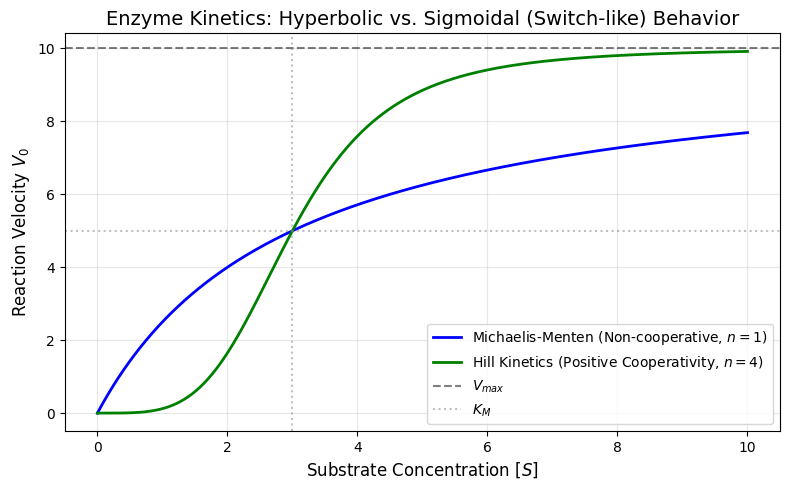

In [3]:
# Generate data for the two types of curves
S = np.linspace(0, 10, 500)
Vmax = 10
Km = 3

# Michaelis-Menten (Hyperbolic)
v_mm = Vmax * S / (Km + S)

# Hill Equation (Sigmoidal, n=4)
n = 4
v_hill = Vmax * (S**n) / (Km**n + S**n)

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(S, v_mm, label='Michaelis-Menten (Non-cooperative, $n=1$)', color='blue', linewidth=2)
plt.plot(S, v_hill, label=f'Hill Kinetics (Positive Cooperativity, $n={n}$)', color='green', linewidth=2)

# Add annotations
plt.axhline(Vmax, color='black', linestyle='--', alpha=0.5, label='$V_{max}$')
plt.axhline(Vmax/2, color='gray', linestyle=':', alpha=0.5)
plt.axvline(Km, color='gray', linestyle=':', alpha=0.5, label='$K_M$')

plt.title('Enzyme Kinetics: Hyperbolic vs. Sigmoidal (Switch-like) Behavior', fontsize=14)
plt.xlabel('Substrate Concentration $[S]$', fontsize=12)
plt.ylabel('Reaction Velocity $V_0$', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('cooperativity_graph.png', dpi=300)

***
#### **Part B**
Determine the kinetic parameters of the enzyme.

      HILL KINETICS — FITTED PARAMETERS
  Vmax = 2.5098 ± 0.0514  M/min
  Km   = 1.6391 ± 0.1601  M
  n    = 4.1084 ± 0.7653  (Hill coefficient)
  R²   = 0.99744


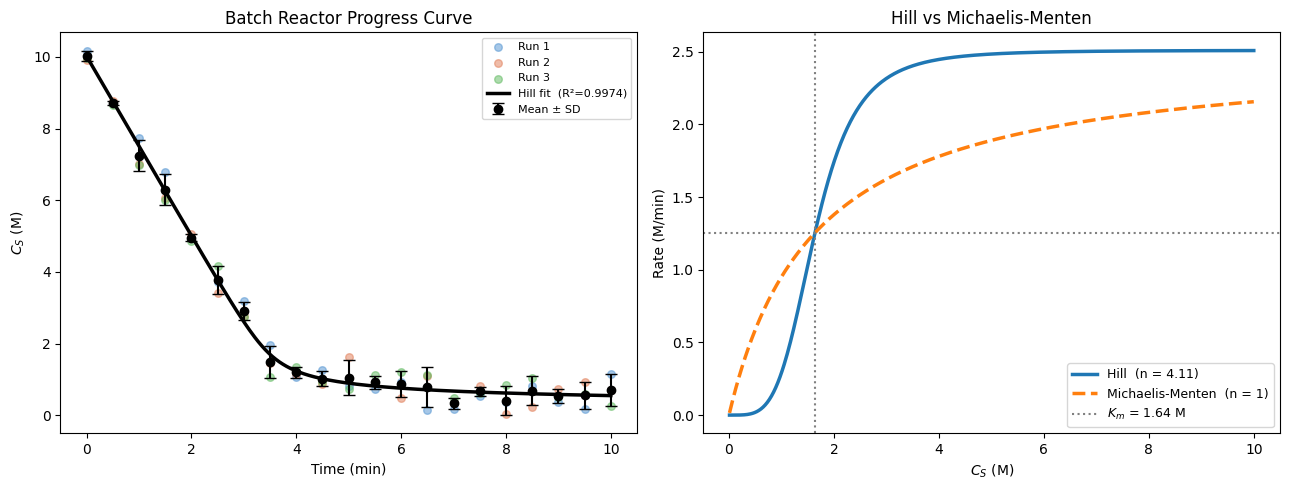

In [6]:
# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_excel("Enzyme data.xls")

t_data = df["Time (min)"].values
runs   = ["Cs_Run1 (M)", "Cs_Run2 (M)", "Cs_Run3 (M)"]

Cs_mean = df[runs].mean(axis=1).values
Cs_std  = df[runs].std(axis=1).values

# Stack all 3 runs for simultaneous fitting
t_all  = np.tile(t_data, 3)
Cs_all = np.concatenate([df[r].values for r in runs])

# Initial substrate concentration (average across runs at t=0)
Cs0 = df[runs].iloc[0].mean()

# ============================================================
# 2. DEFINE ODE AND SIMULATION FUNCTION
# ============================================================
# Batch reactor Hill kinetics:
#   -dCs/dt = Vmax * Cs^n / (Km^n + Cs^n)

def hill_ode(t, Cs, Vmax, Km, n):
    return [-Vmax * Cs[0]**n / (Km**n + Cs[0]**n)]

def simulate_Cs(t_eval, Cs0, Vmax, Km, n):
    sol = solve_ivp(
        hill_ode,
        t_span=[t_eval[0], t_eval[-1]],
        y0=[Cs0],
        args=(Vmax, Km, n),
        t_eval=t_eval,
        method="RK45",
        rtol=1e-8,
        atol=1e-10
    )
    return sol.y[0]

# ============================================================
# 3. OBJECTIVE FUNCTION FOR curve_fit
# ============================================================
# curve_fit passes (t_all, Vmax, Km, n) and expects Cs_all back.
# Since all 3 runs share the same t_data, we simulate once
# and tile the result to match all runs.

def model(t_stacked, Vmax, Km, n):
    Cs_sim = simulate_Cs(t_data, Cs0, Vmax, Km, n)
    return np.tile(Cs_sim, 3)

# ============================================================
# 4. FIT — NONLINEAR LEAST SQUARES
# ============================================================
p0     = [3.0,  2.0, 2.0]           # initial guesses: Vmax, Km, n
bounds = ([0.01, 0.01, 1.0],         # lower bounds
          [50.0, 20.0, 10.0])        # upper bounds

popt, pcov = curve_fit(
    model, t_all, Cs_all,
    p0=p0, bounds=bounds,
    maxfev=10000
)
perr = np.sqrt(np.diag(pcov))       # 1-sigma parameter uncertainties

Vmax_fit, Km_fit, n_fit = popt
Vmax_err, Km_err, n_err = perr

# ============================================================
# 5. GOODNESS OF FIT (R²)
# ============================================================
Cs_sim_fit = simulate_Cs(t_data, Cs0, Vmax_fit, Km_fit, n_fit)
ss_res = np.sum((Cs_mean - Cs_sim_fit)**2)
ss_tot = np.sum((Cs_mean - Cs_mean.mean())**2)
R2 = 1 - ss_res / ss_tot

# ============================================================
# 6. RESULTS
# ============================================================
print("=" * 45)
print("      HILL KINETICS — FITTED PARAMETERS")
print("=" * 45)
print(f"  Vmax = {Vmax_fit:.4f} ± {Vmax_err:.4f}  M/min")
print(f"  Km   = {Km_fit:.4f} ± {Km_err:.4f}  M")
print(f"  n    = {n_fit:.4f} ± {n_err:.4f}  (Hill coefficient)")
print(f"  R²   = {R2:.5f}")
print("=" * 45)

# ============================================================
# 7. PLOT
# ============================================================
t_fine   = np.linspace(0, t_data[-1], 300)
Cs_fine  = simulate_Cs(t_fine, Cs0, Vmax_fit, Km_fit, n_fit)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Progress curve fit ---
ax = axes[0]
colors = ["#4e91d0", "#e07b54", "#5cb85c"]
for i, run in enumerate(runs):
    ax.scatter(t_data, df[run].values, s=30, alpha=0.5,
               color=colors[i], label=f"Run {i+1}")
ax.errorbar(t_data, Cs_mean, yerr=Cs_std, fmt="ko",
            markersize=6, capsize=4, label="Mean ± SD", zorder=5)
ax.plot(t_fine, Cs_fine, "k-", linewidth=2.5,
        label=f"Hill fit  (R²={R2:.4f})")
ax.set_xlabel("Time (min)")
ax.set_ylabel("$C_S$ (M)")
ax.set_title("Batch Reactor Progress Curve")
ax.legend(fontsize=8)

# --- Right: Rate vs Cs (Hill vs MM) ---
ax = axes[1]
Cs_range  = np.linspace(0.01, 10, 500)
rate_hill = Vmax_fit * Cs_range**n_fit / (Km_fit**n_fit + Cs_range**n_fit)
rate_mm   = Vmax_fit * Cs_range         / (Km_fit         + Cs_range)

ax.plot(Cs_range, rate_hill, linewidth=2.5,
        label=f"Hill  (n = {n_fit:.2f})")
ax.plot(Cs_range, rate_mm,   linewidth=2.5, linestyle="--",
        label="Michaelis-Menten  (n = 1)")
ax.axvline(Km_fit, color="gray", linestyle=":", linewidth=1.5,
           label=f"$K_m$ = {Km_fit:.2f} M")
ax.axhline(Vmax_fit / 2, color="gray", linestyle=":", linewidth=1.5)
ax.set_xlabel("$C_S$ (M)")
ax.set_ylabel("Rate (M/min)")
ax.set_title("Hill vs Michaelis-Menten")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("hill_kinetics_fit.png", dpi=150, bbox_inches="tight")
plt.show()

***
## Problem 3

You are designing a cylindrical, capillary-based biosensor to continuously monitor the concentration of a specific metabolite (A). The capillary is extremely long (L=0.5 m). The entrance of the capillary (z=0) is submerged in a fluid stream that maintains a constant metabolite concentration of CA0​=10 mol/m3. The fluid within the capillary is completely stagnant and dilute. At the far end of the capillary (z=L), an engineered enzyme is immobilized uniformly across the flat circular base to catalyze the breakdown of A.

While characterizing this enzyme, you noticed a strange phenomenon. The enzyme possesses an unusually large active site volume. At higher concentrations, two molecules of A can simultaneously diffuse into and bind to the active site. However, this dual-bound orientation is sterically hindered and completely non-reactive, trapping the enzyme until one of the molecules dissociates.

The system parameters are:

- Diffusivity of A in the fluid (DA​): 2x10−6 m2/s
- Maximum surface reaction velocity (vmax​): 5x10−4 mol/(m2 s)
- Michaelis-Menten constant (KM​): 2 mol/m3
- Dissociation constant of the non-reactive dual-bound complex (KD​): 5 mol/m3

#### **Part A**
Based on the physical description of the active site, write the exact reaction rate expression (v​) for this immobilized enzyme as a function of the local concentration of A (CA​).

In [ ]:
# enter code here

***
#### **Part B**
Write the governing ordinary differential equation (ODE) that describes the concentration profile of A along the axial length (z) of the cylindrical capillary. Next, write the two boundary conditions required to solve this system. 

***
#### **Part C**
Plot the concentration profile CA​(z)

## Problem 4

[insert question]

In [ ]:
# enter code here

## Problem 5

[insert question]

In [ ]:
# enter code here

## Problem 6

[insert question]

In [1]:
# enter code here